# Visión Artificial

## ¿Qué es la visión artificial?

La **visión artificial** es una tecnología que permite a las computadoras capturar, procesar y analizar imágenes o videos para identificar objetos, personas, formas, colores y diferentes características del entorno.

Está relacionada con la **inteligencia artificial (IA)** y utiliza técnicas de procesamiento de imágenes, aprendizaje automático y redes neuronales.

## ¿Cómo funciona?

La visión artificial funciona mediante un proceso de varias etapas:

1. **Captura de la imagen:** una cámara o sensor obtiene una imagen o video.
2. **Procesamiento:** la imagen es preparada para facilitar su análisis.
3. **Análisis:** el sistema identifica características, objetos o patrones.
4. **Interpretación:** un modelo de inteligencia artificial interpreta la información.
5. **Resultado:** el sistema genera una respuesta o toma una decisión.

## Aplicaciones de la visión artificial

- **Medicina:** análisis de radiografías, tomografías y otras imágenes médicas.
- **Seguridad:** reconocimiento facial, vigilancia y detección de objetos.
- **Industria:** control de calidad, detección de productos defectuosos y automatización.
- **Agricultura:** detección de enfermedades en cultivos y análisis de plantas.
- **Transporte:** reconocimiento de vehículos, peatones, señales y carriles.
- **Comercio:** reconocimiento de productos, inventarios y sistemas de pago.
- **Aplicaciones móviles:** reconocimiento de imágenes, documentos y objetos.

# Detección de rostros con Python usando OpenCV

In [1]:
# 1. Instalación (solo si hace falta; usar OpenCV 4.x porque la 5.x eliminó CascadeClassifier de Python)
# pip install "opencv-python==4.12.0.88" matplotlib

# 2. Importación de la librería
import cv2

# 3. Cargar imagen
imgpath = 'diverso-de-rostros-humanos-en-fila-43694850.webp'
img = cv2.imread(imgpath)
assert img is not None, f"No se pudo leer la imagen: {imgpath}"

# 4. Mostrar versión y dimensiones
print("version:", cv2.__version__)
img.shape

version: 4.12.0


(800, 800, 3)

In [2]:
# 5. Convertir la imagen a escala de grises
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img.shape

(800, 800)

In [3]:
# 6. Cargar el clasificador de rostros (Haar cascade)
cascade = "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade)

# Verificar si el clasificador se cargó correctamente
if face_cascade.empty():
    print("Error al cargar el clasificador de rostros.")
else:
    print("Clasificador de rostros cargado correctamente.")

Clasificador de rostros cargado correctamente.


In [4]:
# 7. Detectar rostros
faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
print("Rostros detectados:", len(faces))

Rostros detectados: 16


In [5]:
# 8. Dibujar un rectángulo rojo alrededor de cada rostro detectado
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

# 9. Las imágenes se cargan en formato BGR, pero matplotlib utiliza RGB, por lo que debemos convertir la imagen a RGB antes de mostrarla.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

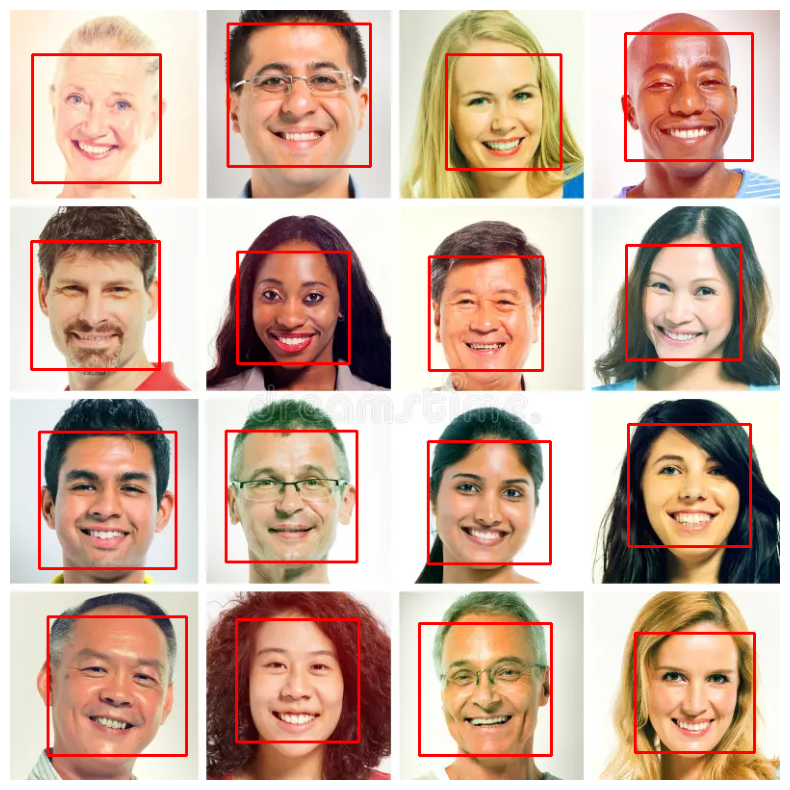

Imagen guardada como resultado.jpg


In [6]:
# 10. Importar matplotlib y mostrar el resultado
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# 11. Guardar el resultado
cv2.imwrite("resultado.jpg", img)
print("Imagen guardada como resultado.jpg")

## Captura de video en tiempo real

In [7]:
# 1. Acceder a la camara de nuestro pc y leer un flujo de datos en tiempo real 
video_capture = cv2.VideoCapture(0)

# 2. Función para detectar rostros con flujo de video y dibujar un recuadro delimitador
def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    face = face_cascade.detectMultiScale(gray_img, 1.1, 2, minSize=(40, 40))
    for (x, y, w, h) in face:
        cv2.rectangle(vid, (x, y), (x+w, y+h), (255, 0, 0), 2)
    return face

In [8]:
#  3. Bucle while apra decyectar caras en real time ,capturar fotografia 
while True:
    
    result, video_frame = video_capture.read()
    
    if result is False:
        break
    face = detect_bounding_box(video_frame)
    
    cv2.imshow("mi cara detectada", video_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

video_capture.release()
cv2.destroyAllWindows()